# Display of experiments

## Prepare the ressources

In [49]:
!pip install pyagrum
!pip install numpy
!pip install causal-learn
!pip install pandas
!pip install pingouin
!pip install bnlearn
!pip install graphviz
!pip install IPython

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [50]:
import sys
import os
sys.path.append(os.getcwd())

In [51]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
from FCI import *
import graphviz
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, chisq
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

mr = gum.MeekRules()

## Experiment on a given defined database

In [52]:
# bif_file= 'sprinkler'
# bif_file= 'alarm'
# bif_file= 'andes'
bif_file= 'asia'
# bif_file= 'sachs'
# bif_file= 'miserables'
model = bn.import_DAG(bif_file)

[bnlearn] >Import <asia>
[bnlearn] >Loading bif file <C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


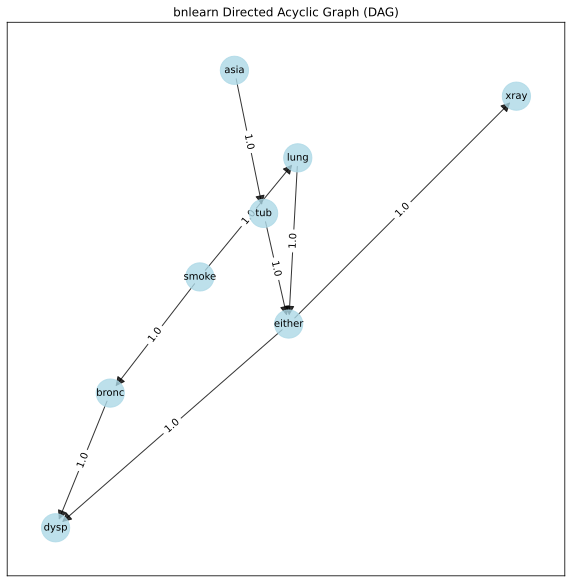

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'asia': array([-0.04214123,  0.30080582]),
  'tub': array([0.06576034, 0.07084016]),
  'either': array([ 0.15828369, -0.10706323]),
  'smoke': array([-0.16989143, -0.03130676]),
  'lung': array([0.19196894, 0.16012456]),
  'bronc': array([-0.50092264, -0.21807574]),
  'dysp': array([-0.70305767, -0.43456937]),
  'xray': array([1.        , 0.25924455])},
 'G': <networkx.classes.digraph.DiGraph at 0x1c5c092b360>,
 'node_properties': {'asia': {'node_color': '#ADD8E6', 'node_size': 800},
  'tub': {'node_color': '#ADD8E6', 'node_size': 800},
  'smoke': {'node_color': '#ADD8E6', 'node_size': 800},
  'lung': {'node_color': '#ADD8E6', 'node_size': 800},
  'bronc': {'node_color': '#ADD8E6', 'node_size': 800},
  'either': {'node_color': '#ADD8E6', 'node_size': 800},
  'xray': {'node_color': '#ADD8E6', 'node_size': 800},
  'dysp': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('a

In [53]:
bn.plot(model)

In [54]:
df = bn.sampling(model, n=100000)
df

,asia,tub,smoke,lung,bronc,either,xray,dysp
0,1,1,0,1,1,1,1,0
1,1,1,0,1,0,1,1,0
2,1,1,1,1,1,1,1,1
3,1,1,0,1,0,1,1,0
4,1,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...
99995,1,1,0,0,1,0,0,0
99996,1,1,1,1,1,1,1,1
99997,1,1,0,1,1,1,1,1
99998,1,1,0,1,0,1,1,0


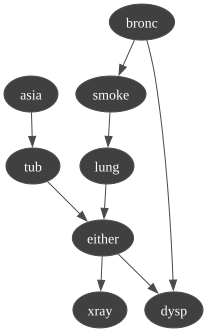

In [55]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

  0%|          | 0/8 [00:00<?, ?it/s]

0 dep 1 | () with p-value 0.000000

0 ind 2 | () with p-value 0.431654

0 ind 3 | () with p-value 0.933160

0 ind 4 | () with p-value 0.799347

0 dep 5 | () with p-value 0.000000

0 dep 6 | () with p-value 0.000005

0 ind 7 | () with p-value 0.120857

1 dep 0 | () with p-value 0.000000

1 dep 2 | () with p-value 0.014950

1 ind 3 | () with p-value 0.945356

1 ind 4 | () with p-value 0.658800

1 dep 5 | () with p-value 0.000000

1 dep 6 | () with p-value 0.000000

1 dep 7 | () with p-value 0.000000

2 ind 0 | () with p-value 0.431654

2 dep 1 | () with p-value 0.014950

2 dep 3 | () with p-value 0.000000

2 dep 4 | () with p-value 0.000000

2 dep 5 | () with p-value 0.000000

2 dep 6 | () with p-value 0.000000

2 dep 7 | () with p-value 0.000000

3 ind 0 | () with p-value 0.933160

3 ind 1 | () with p-value 0.945356

3 dep 2 | () with p-value 0.000000

3 dep 4 | () with p-value 0.000000

3 dep 5 | () with p-value 0.000000

3 dep 6 | () with p-value 0.000000

3 dep 7 | () with p-value 0.

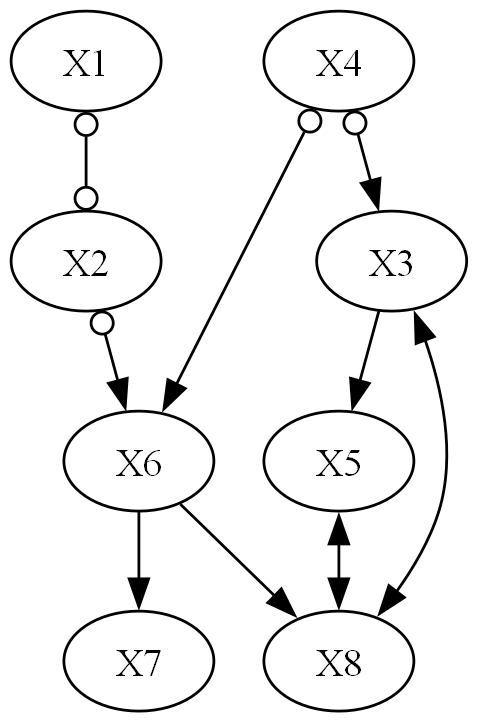

In [56]:
graph, sep_sets = fci(
    df.to_numpy(),
    ci_test=fisherz,
    alpha=0.05,
    verbose=True,
)
node_names = list(df.columns)
pdy = GraphUtils.to_pydot(graph)
display(Image(pdy.create_png()))

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' '>' ' ' ' ' '>']
 [' ' ' ' '>' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' 'o' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' '>' ' ' '>' '-' ' ' ' ']]


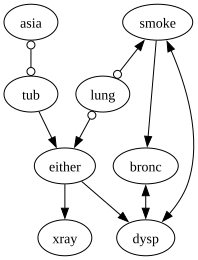

In [57]:
fci_final = run_FCI(df, 0.05, useGum=False)
print(fci_final.matrix)
graph = fci_final.toDot()
graph

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' '>' ' ' ' ' '>']
 [' ' ' ' '>' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' 'o' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' '>' ' ' '>' '-' ' ' ' ']]


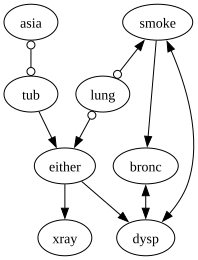

In [58]:
rfci = run_RFCI(df, 0.05, useGum=False)
print(rfci.matrix)
graph = rfci.toDot()
graph

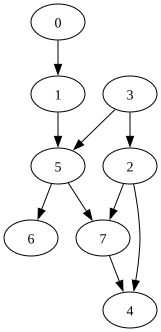

In [59]:
pdag = fci_final.return_PDAG()
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

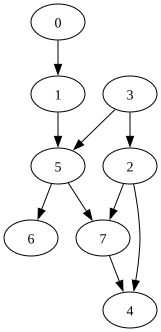

In [60]:
pdag = rfci.return_PDAG()
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

## Experiment on a randomly given database

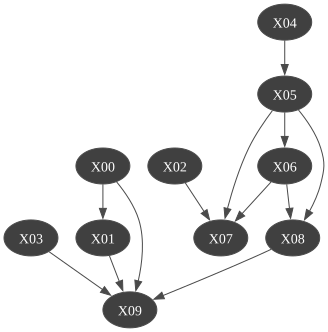

In [61]:
n = 10 # Modify this parameter
domain_size = 2 # Modify this parameter

bayesnet = gum.randomBN(n=n, domain_size=domain_size)
gnb.showBN(bayesnet)

In [62]:
g = gum.BNDatabaseGenerator(bayesnet)
g.setRandomVarOrder()
g.setDiscretizedLabelModeRandom()
g.drawSamples(100000)
df = g.to_pandas()
for col in df.columns:
    df[col] = df[col].astype('category').cat.codes
df

,X01,X08,X02,X00,X07,X06,X04,X05,X09,X03
0,0,1,0,1,0,0,1,1,1,0
1,1,1,1,0,0,0,0,1,1,1
2,0,1,1,1,0,0,0,0,1,1
3,1,0,0,1,1,0,0,1,0,1
4,0,0,0,0,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
99995,0,0,1,1,0,0,0,0,1,0
99996,1,0,1,0,0,0,1,1,1,1
99997,1,1,1,0,1,0,0,0,1,1
99998,1,0,0,0,1,0,0,0,1,1


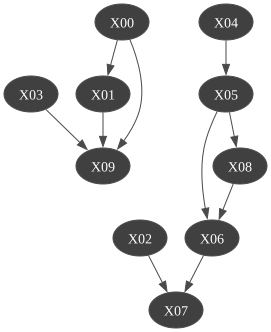

In [63]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

[[' ' '>' ' ' 'o' ' ' ' ' ' ' ' ' '>' ' ']
 ['>' ' ' ' ' ' ' ' ' '>' 'o' 'o' ' ' ' ']
 [' ' ' ' ' ' ' ' '>' ' ' ' ' ' ' '>' ' ']
 ['>' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '>' ' ']
 [' ' ' ' '>' ' ' ' ' '>' ' ' ' ' ' ' ' ']
 [' ' '>' ' ' ' ' '>' ' ' ' ' '-' ' ' ' ']
 [' ' '>' ' ' ' ' ' ' ' ' ' ' 'o' ' ' ' ']
 [' ' '>' ' ' ' ' ' ' '>' 'o' ' ' ' ' ' ']
 ['>' ' ' '>' 'o' ' ' ' ' ' ' ' ' ' ' 'o']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '>' ' ']]


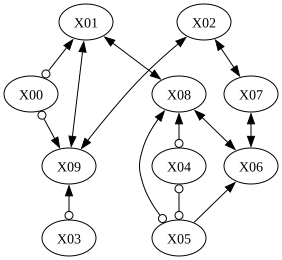

In [64]:
fci_final_pg = run_FCI(df, 0.05, useGum=False, bayesnet=bayesnet)
print(fci_final_pg.matrix)
graph = fci_final_pg.toDot()
graph

[[' ' ' ' ' ' 'o' ' ' ' ' ' ' ' ' '>' ' ']
 [' ' ' ' ' ' ' ' ' ' '>' ' ' 'o' ' ' ' ']
 [' ' ' ' ' ' ' ' '>' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '>' ' ']
 [' ' ' ' 'o' ' ' ' ' '>' ' ' ' ' ' ' ' ']
 [' ' 'o' ' ' ' ' '>' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' 'o' ' ' ' ' ' ' '>' 'o' ' ' ' ' ' ']
 ['o' ' ' ' ' 'o' ' ' ' ' ' ' ' ' ' ' 'o']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' '>' ' ']]


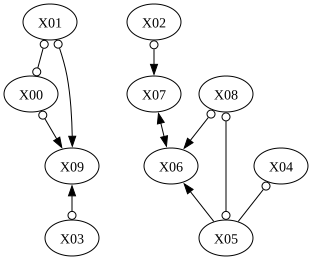

In [65]:
fci_final_gum = run_FCI(df, 0.05, useGum=True, bayesnet=bayesnet)
print(fci_final_gum.matrix)
graph = fci_final_gum.toDot()
graph

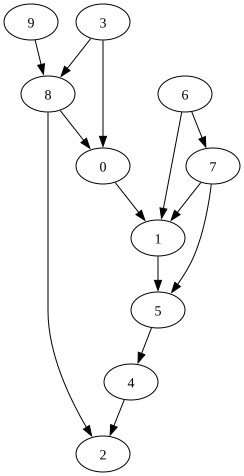

In [66]:
pdag = fci_final_pg.return_PDAG()
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

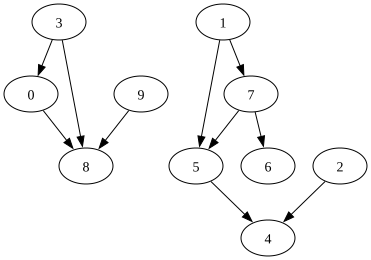

In [67]:
pdag = fci_final_gum.return_PDAG()
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph